In [51]:
from pathlib import Path
import numpy as np
import pandas as pd

In [52]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "credit_risk_dataset.csv"

print(DATA_PATH)
print("File exists:", DATA_PATH.exists())

/Users/marijacolic/PycharmProjects/credit-risk-portfolio-analysis/data/raw/credit_risk_dataset.csv
File exists: True


In [53]:
df = pd.read_csv(DATA_PATH)

In [54]:
clean_df = df.copy()

## Baseline Logistic Regression Model

This section builds an initial logistic regression model using the available borrower and loan features, including `loan_grade`.


In [55]:
target = "loan_status"

features = [
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "loan_intent",
    "loan_grade",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_default_on_file",
    "cb_person_cred_hist_length"
]

X = clean_df[features]
y = clean_df[target]

In [56]:
numerical_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [59]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolum

In [60]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

predicted_classes = model.predict(X_test)
predicted_probabilities = model.predict_proba(
    X_test
)[:, 1]

print(classification_report(
    y_test,
    predicted_classes
))

print("Confusion matrix:")
print(confusion_matrix(
    y_test,
    predicted_classes
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        predicted_probabilities
    )
)

              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5095
           1       0.55      0.78      0.65      1422

    accuracy                           0.81      6517
   macro avg       0.74      0.80      0.76      6517
weighted avg       0.85      0.81      0.82      6517

Confusion matrix:
[[4199  896]
 [ 313 1109]]
ROC-AUC: 0.8711466662249883


In [61]:
results = X_test.copy()

results["actual_default"] = y_test.values
results["predicted_default_probability"] = (
    predicted_probabilities
)

results["risk_band"] = pd.cut(
    results["predicted_default_probability"],
    bins=[0, 0.10, 0.25, 0.50, 1.00],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    include_lowest=True
)

In [62]:
risk_band_summary = (
    results.groupby(
        "risk_band",
        observed=False
    )
    .agg(
        applicant_count=(
            "actual_default",
            "size"
        ),
        actual_default_rate=(
            "actual_default",
            "mean"
        ),
        average_predicted_probability=(
            "predicted_default_probability",
            "mean"
        )
    )
    .reset_index()
)

risk_band_summary[
    "actual_default_rate"
] *= 100

risk_band_summary[
    "average_predicted_probability"
] *= 100

risk_band_summary

,risk_band,applicant_count,actual_default_rate,average_predicted_probability
0,Low,1137,1.759015,5.915856
1,Moderate,1823,6.692265,16.644282
2,High,1552,11.018041,35.937653
3,Very High,2005,55.311721,77.199119


## Model Comparison: With vs. Without Loan Grade

Loan grade may already represent an existing assessment of borrower risk. To evaluate how strongly the model depends on this variable, two logistic regression models are compared:

- **Model A** includes `loan_grade`.
- **Model B** excludes `loan_grade`.

Both models use the same train-test split and the same logistic regression settings. They are compared using ROC-AUC, precision, recall, F1-score, confusion matrices, and ROC curves.


In [63]:
# Define the target once for both models
target = "loan_status"
y = clean_df[target]

# Model A: features WITH loan grade
features_with_grade = [
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "loan_intent",
    "loan_grade",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_default_on_file",
    "cb_person_cred_hist_length"
]

# Model B: features WITHOUT loan grade
features_without_grade = [
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "loan_intent",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_default_on_file",
    "cb_person_cred_hist_length"
]

X_with_grade = clean_df[features_with_grade]
X_without_grade = clean_df[features_without_grade]

print("Features with grade:", len(features_with_grade))
print("Features without grade:", len(features_without_grade))


Features with grade: 11
Features without grade: 10


In [64]:
# Create ONE train-test split so both models are evaluated on exactly the same observations
from sklearn.model_selection import train_test_split

train_index, test_index = train_test_split(
    clean_df.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train_with_grade = X_with_grade.loc[train_index]
X_test_with_grade = X_with_grade.loc[test_index]

X_train_without_grade = X_without_grade.loc[train_index]
X_test_without_grade = X_without_grade.loc[test_index]

y_train_comparison = y.loc[train_index]
y_test_comparison = y.loc[test_index]

print("Training observations:", len(train_index))
print("Test observations:", len(test_index))


Training observations: 26064
Test observations: 6517


In [65]:
# Define numerical and categorical variables for each model
numerical_features_comparison = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

categorical_features_with_grade = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

categorical_features_without_grade = [
    "person_home_ownership",
    "loan_intent",
    "cb_person_default_on_file"
]


In [66]:
# Create preprocessing pipelines
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_pipeline_comparison = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline_comparison = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocessor_with_grade = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline_comparison,
            numerical_features_comparison
        ),
        (
            "categorical",
            categorical_pipeline_comparison,
            categorical_features_with_grade
        )
    ]
)

preprocessor_without_grade = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline_comparison,
            numerical_features_comparison
        ),
        (
            "categorical",
            categorical_pipeline_comparison,
            categorical_features_without_grade
        )
    ]
)


In [67]:
# Build and train Model A: WITH loan grade
from sklearn.linear_model import LogisticRegression

model_with_grade = Pipeline(
    steps=[
        ("preprocessor", preprocessor_with_grade),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

model_with_grade.fit(
    X_train_with_grade,
    y_train_comparison
)

print("Model A trained successfully.")


Model A trained successfully.


In [68]:
# Build and train Model B: WITHOUT loan grade
model_without_grade = Pipeline(
    steps=[
        ("preprocessor", preprocessor_without_grade),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

model_without_grade.fit(
    X_train_without_grade,
    y_train_comparison
)

print("Model B trained successfully.")


Model B trained successfully.


In [69]:
# Generate predicted classes and default probabilities for both models
pred_with_grade = model_with_grade.predict(
    X_test_with_grade
)

prob_with_grade = model_with_grade.predict_proba(
    X_test_with_grade
)[:, 1]

pred_without_grade = model_without_grade.predict(
    X_test_without_grade
)

prob_without_grade = model_without_grade.predict_proba(
    X_test_without_grade
)[:, 1]

print("Predictions created for both models.")


Predictions created for both models.


In [70]:
# Calculate evaluation metrics for both models
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

metrics_with_grade = {
    "ROC-AUC": roc_auc_score(
        y_test_comparison,
        prob_with_grade
    ),
    "Precision": precision_score(
        y_test_comparison,
        pred_with_grade,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_comparison,
        pred_with_grade,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test_comparison,
        pred_with_grade,
        zero_division=0
    )
}

metrics_without_grade = {
    "ROC-AUC": roc_auc_score(
        y_test_comparison,
        prob_without_grade
    ),
    "Precision": precision_score(
        y_test_comparison,
        pred_without_grade,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_comparison,
        pred_without_grade,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test_comparison,
        pred_without_grade,
        zero_division=0
    )
}


In [71]:
# Create a side-by-side comparison table
comparison = pd.DataFrame(
    {
        "Model A - With Loan Grade": metrics_with_grade,
        "Model B - Without Loan Grade": metrics_without_grade
    }
).T

comparison.round(3)


,ROC-AUC,Precision,Recall,F1 Score
Model A - With Loan Grade,0.871,0.553,0.780,0.647
Model B - Without Loan Grade,0.856,0.488,0.779,0.600


In [72]:
# Calculate the change in ROC-AUC from including loan grade
auc_difference = (
    metrics_with_grade["ROC-AUC"]
    - metrics_without_grade["ROC-AUC"]
)

print(
    f"ROC-AUC improvement from including loan grade: "
    f"{auc_difference:.3f}"
)


ROC-AUC improvement from including loan grade: 0.015


### Classification Reports

For the classification reports below, pay particular attention to **class 1**, because `loan_status = 1` represents default. In a credit-risk context, recall for class 1 tells us how many actual defaults the model successfully identifies.


In [73]:
from sklearn.metrics import classification_report

print("MODEL A - WITH LOAN GRADE")
print(
    classification_report(
        y_test_comparison,
        pred_with_grade,
        zero_division=0
    )
)

print("MODEL B - WITHOUT LOAN GRADE")
print(
    classification_report(
        y_test_comparison,
        pred_without_grade,
        zero_division=0
    )
)


MODEL A - WITH LOAN GRADE
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5095
           1       0.55      0.78      0.65      1422

    accuracy                           0.81      6517
   macro avg       0.74      0.80      0.76      6517
weighted avg       0.85      0.81      0.82      6517

MODEL B - WITHOUT LOAN GRADE
              precision    recall  f1-score   support

           0       0.93      0.77      0.84      5095
           1       0.49      0.78      0.60      1422

    accuracy                           0.77      6517
   macro avg       0.71      0.78      0.72      6517
weighted avg       0.83      0.77      0.79      6517



### Confusion Matrices

The confusion matrix is arranged as:

`[[True Negatives, False Positives], [False Negatives, True Positives]]`

For credit risk, false negatives are especially important because they are borrowers who actually defaulted but were predicted as non-defaults.


In [74]:
from sklearn.metrics import confusion_matrix

cm_with_grade = confusion_matrix(
    y_test_comparison,
    pred_with_grade
)

cm_without_grade = confusion_matrix(
    y_test_comparison,
    pred_without_grade
)

print("Confusion Matrix - Model A (With Loan Grade)")
print(cm_with_grade)

print("Confusion Matrix - Model B (Without Loan Grade)")
print(cm_without_grade)


Confusion Matrix - Model A (With Loan Grade)
[[4199  896]
 [ 313 1109]]
Confusion Matrix - Model B (Without Loan Grade)
[[3933 1162]
 [ 314 1108]]


### ROC Curve Comparison

The ROC curve shows the trade-off between the true positive rate and false positive rate across classification thresholds. A curve closer to the upper-left corner indicates better discrimination.


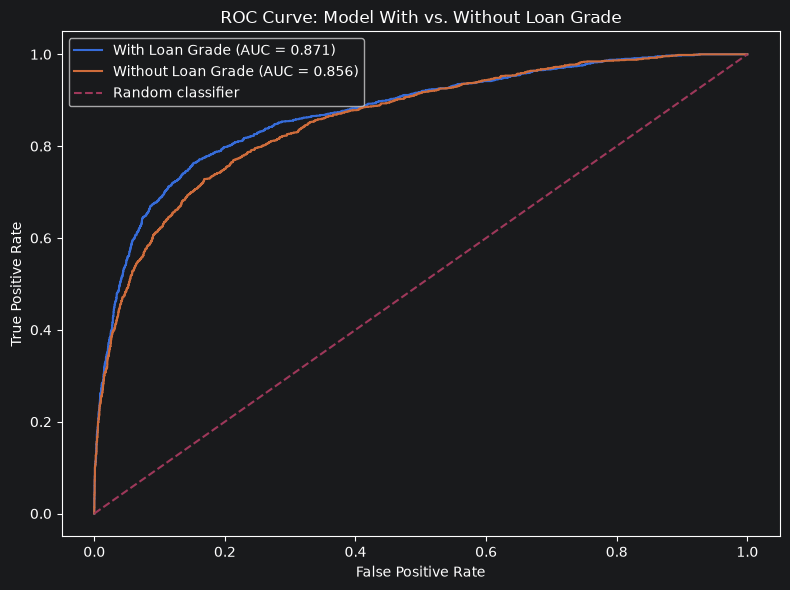

In [75]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_with, tpr_with, _ = roc_curve(
    y_test_comparison,
    prob_with_grade
)

fpr_without, tpr_without, _ = roc_curve(
    y_test_comparison,
    prob_without_grade
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_with,
    tpr_with,
    label=(
        f"With Loan Grade "
        f"(AUC = {metrics_with_grade['ROC-AUC']:.3f})"
    )
)

plt.plot(
    fpr_without,
    tpr_without,
    label=(
        f"Without Loan Grade "
        f"(AUC = {metrics_without_grade['ROC-AUC']:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Model With vs. Without Loan Grade")
plt.legend()
plt.tight_layout()
plt.show()


## Interpretation

The model including loan grade achieved a **ROC-AUC of 0.871**, compared with **0.856** for the model without loan grade.

Including loan grade therefore improved ROC-AUC by approximately **0.015**. This is a relatively small improvement, suggesting that the model retains much of its ability to distinguish between defaulting and non-defaulting borrowers even when the lender-assigned loan grade is excluded.

The model with loan grade achieved a default recall of **78.0%**, while the model without loan grade achieved **77.9%**. The difference in recall is therefore very small: both models identified approximately 78% of the borrowers who actually defaulted.

A more noticeable difference can be observed in **precision**. The model with loan grade achieved a default precision of **55.3%**, compared with **48.8%** without loan grade. This means that when the model predicted a default, the prediction was more often correct when loan grade was included.

The F1-score also decreased from **0.647** with loan grade to **0.600** without it, indicating that including loan grade provided a better overall balance between precision and recall.

### Confusion Matrix Comparison

| Result | With Loan Grade | Without Loan Grade |
|---|---:|---:|
| Correctly identified non-defaults (True Negatives) | 4,199 | 3,933 |
| Incorrectly predicted defaults (False Positives) | 896 | 1,162 |
| Missed actual defaults (False Negatives) | 313 | 314 |
| Correctly identified defaults (True Positives) | 1,109 | 1,108 |

The confusion matrices provide additional insight into how `loan_grade` affects model performance. Removing loan grade barely changed the model's ability to identify actual defaults: the number of correctly identified defaults decreased only from **1,109 to 1,108**, while missed defaults increased from **313 to 314**.

However, excluding loan grade resulted in substantially more false-positive default predictions. The number of non-defaulting borrowers incorrectly classified as defaults increased from **896 to 1,162**.

Therefore, in this model, `loan_grade` contributes primarily to **precision rather than recall**. It helps the model avoid incorrectly classifying non-defaulting borrowers as high risk while having relatively little effect on the number of actual defaults detected.

### Conclusion

Overall, the results suggest that `loan_grade` contains useful predictive information, particularly for reducing false-positive default predictions. However, the relatively small difference in ROC-AUC and recall shows that the remaining borrower and loan characteristics still contain substantial information about default risk.

Since `loan_grade` may already summarize part of an existing lender credit-risk assessment, its predictive contribution should be interpreted carefully. Comparing both models demonstrates that the default model does not rely exclusively on the lender-assigned grade and can still identify a substantial proportion of defaults without it.

For this analysis, the model including `loan_grade` provides the stronger overall performance, while the model without `loan_grade` serves as a useful comparison for understanding how much predictive information is already contained in the lender-assigned grade.

## Model Limitations

The logistic regression model developed in this project is intended as an
educational demonstration of credit risk modelling rather than a production
credit decision system.

Several limitations should be considered:

- The dataset does not represent a live lending portfolio and may not capture
  all factors used in real-world credit decisions.
- The analysis uses a single train-test split rather than an out-of-time
  validation sample.
- The model estimates the probability of default but does not incorporate
  other components of credit loss, such as loss given default (LGD) or
  exposure at default (EAD).
- The classification threshold and risk-band thresholds were selected for
  analytical purposes and have not been optimized according to a lender's
  business costs or risk appetite.
- `loan_grade` may already contain information from an existing lender risk
  assessment, which is why model performance was also evaluated without this
  variable.
- A production credit model would require additional validation, monitoring,
  fairness testing, regulatory review, and ongoing performance assessment.

Despite these limitations, the analysis demonstrates how borrower and loan
characteristics can be used to estimate default risk and how model performance
can be evaluated from both statistical and credit-risk perspectives.